# Text as Data: dos hipótesis, un corpus
Doctorado en Ciencia Política — UNMSM · Métodos Cuantitativos (2026)

**Puzzle:** ¿Hasta qué punto los partidos convergen en sus propuestas pese a diferenciarse ideológicamente?
**Unidad de análisis:** un plan completo por partido; los fragmentos son unidades de procesamiento.
Pregunta → hipótesis → evidencia → representación → técnica. Buscamos explicar e interpretar diferencias discursivas, no predecir elecciones ni identificar causas.

**H1:** convergencia programática → similitud semántica → SBERT + coseno (no supervisado en este corpus).
**H2:** diferenciación ideológica → posiciones relativas → mismo espacio + eje anclado A–H (orientado por el investigador).

Única lectura asignada: [Ceron, Blokker y Padó (2022)](https://aclanthology.org/2022.conll-1.22/). H2 es una extensión de esta guía; ese artículo no propone el eje A–H. No se replica su validación externa ni su ajuste del modelo.

## TEXT-01: leer el corpus preparado
En Colab, conserve los dos archivos de preparación en la carpeta de trabajo. La primera carga del modelo necesita internet; no requiere entrenamiento. Matplotlib se utiliza únicamente para gráficos.

In [1]:
%pip -q install sentence-transformers numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import csv, json, re, hashlib, importlib.metadata
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
ROOT = Path.cwd()
OUT = ROOT/'resultados'; OUT.mkdir(exist_ok=True)
with open(ROOT/'planes_gobierno_preparados.csv', encoding='utf-8') as f:
    corpus = sorted(list(csv.DictReader(f)), key=lambda r:r['id_partido'])
ids = [r['id_partido'] for r in corpus]
assert ids == list('ABCDEFGH')
pages = json.loads((ROOT/'paginas_preparadas.json').read_text(encoding='utf-8'))
assert all(' '.join(p['texto'] for p in pages if p['id_partido']==r['id_partido'] and p['texto']) == r['texto'] for r in corpus)


## TEXT-02: segmentar sin truncamiento silencioso
**Intuición:** el modelo recibe fragmentos; cada plan sigue siendo una observación. Usamos separación simple por puntuación (revise abreviaturas) y dividimos oraciones largas por palabras hasta respetar el límite real del tokenizador. No requiere otra biblioteca lingüística. Guardamos partido, página y texto para volver a la fuente.

In [3]:
from sentence_transformers import SentenceTransformer
MODEL = 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2'
model = SentenceTransformer(MODEL)
tokenizer = model.tokenizer
LIMIT = model.max_seq_length
def n_tokens(text):
    return len(tokenizer.encode(text, add_special_tokens=True, truncation=False))
def split_safe(text):
    # Se conserva todo el contenido; ninguna ventana se solapa.
    for sentence in re.split(r'(?<=[.!?])\s+', text.strip()):
        current = []
        for word in sentence.split():
            assert n_tokens(word) <= LIMIT, 'Token anómalo muy largo: revise extracción.'
            if current and n_tokens(' '.join(current+[word])) > LIMIT:
                yield ' '.join(current)
                current = []
            current.append(word)
        if current:
            yield ' '.join(current)
chunks=[]
for p in pages:
    parts=list(split_safe(p['texto']))
    assert ' '.join(parts) == ' '.join(p['texto'].split())
    for text in parts:
        chunks.append({'id_partido':p['id_partido'], 'pagina':p['pagina'], 'texto':text, 'tokens':n_tokens(text)})
assert chunks and max(c['tokens'] for c in chunks)<=LIMIT
for party in ids:
    print(party, sum(c['id_partido']==party for c in chunks), 'fragmentos')
print('Límite:', LIMIT, 'tokens, incluidos tokens especiales')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

A 5 fragmentos
B 5 fragmentos
C 5 fragmentos
D 5 fragmentos
E 5 fragmentos
F 5 fragmentos
G 5 fragmentos
H 5 fragmentos
Límite: 128 tokens, incluidos tokens especiales


## TEXT-03: embeddings y agregación documental
Promediamos vectores normalizados de fragmentos con igual peso; luego normalizamos el promedio. Esta decisión da igual peso a cada fragmento, no a cada palabra. La segmentación y las repeticiones pueden afectar el resultado. El promedio pierde matices internos; no convierte el plan en una posición política validada.

In [4]:
E = model.encode([c['texto'] for c in chunks], normalize_embeddings=True, batch_size=16, show_progress_bar=True)
E = np.asarray(E, dtype=float)
raw = np.vstack([E[[c['id_partido']==party for c in chunks]].mean(axis=0) for party in ids])
assert np.all(np.linalg.norm(raw, axis=1)>1e-10)
D = normalize(raw)
assert np.isfinite(D).all()
np.savez_compressed(OUT/'embeddings.npz', fragmentos=E, documentos=D)


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

## TEXT-04: H1, matriz y mapa de similitudes
**Cuidado:** no aplicamos whitening. Con pocos documentos, una covarianza en cientos de dimensiones es singular. Una extensión requeriría muchos fragmentos, regularización/reducción dimensional y validación externa. Normalizar la longitud no equivale a whitening. La anisotropía puede elevar todos los cosenos: no interprete un valor alto como porcentaje de acuerdo ni use un umbral universal.

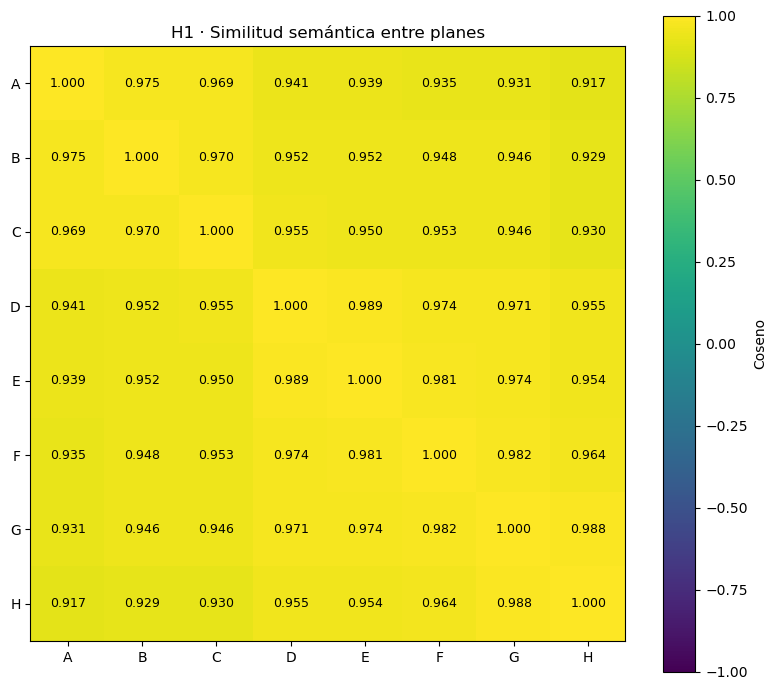

28 pares únicos; media: 0.9561018046745389 
Menor: ('A', 'H', 0.9171590924701432) 
Mayor: ('D', 'E', 0.9885499486335874)


In [5]:
S = cosine_similarity(D)
assert np.allclose(S,S.T) and np.allclose(np.diag(S),1)
with open(OUT/'similitud.csv','w',newline='',encoding='utf-8') as f:
    w=csv.writer(f); w.writerow(['partido']+ids); w.writerows([[party]+list(row) for party,row in zip(ids,S)])
fig, ax=plt.subplots(figsize=(8,7))
im=ax.imshow(S,vmin=-1,vmax=1,cmap='viridis')
ax.set(xticks=range(8),yticks=range(8),xticklabels=ids,yticklabels=ids,title='H1 · Similitud semántica entre planes')
for i in range(8):
    for j in range(8): ax.text(j,i,f'{S[i,j]:.3f}',ha='center',va='center',fontsize=9)
fig.colorbar(im,ax=ax,label='Coseno'); fig.tight_layout(); fig.savefig(OUT/'similitud.png',dpi=180); plt.show()
pairs = [(ids[i],ids[j],float(S[i,j])) for i in range(8) for j in range(i+1,8)]
pairs.sort(key=lambda p:p[2])
mean_cos=float(np.mean([p[2] for p in pairs]))
print('28 pares únicos; media:',mean_cos,'\nMenor:',pairs[0],'\nMayor:',pairs[-1])


## TEXT-05: interpretar H1
Compare los pares extremos y lea sus fragmentos (TEXT-08). Distinga compartir problemas de compartir soluciones. ¿Son próximas las propuestas o solo los temas y el estilo? Sin referencia externa independiente no concluya que H1 está confirmada. Ceron et al. comparan similitudes con posiciones de Wahl-o-Mat; aquí solo hacemos una exploración descriptiva de planes ficticios.

## TEXT-06: H2, definir el eje A–H
Lea A y H y justifique A como polo izquierdo y H como derecho, preferentemente en la dimensión económica. El significado proviene de esa decisión, no de SBERT. Dos planes difieren también en temas y estilo. La separación A–H está impuesta y no constituye evidencia de H2. Examine B–G.

Con $a=D_A$, $h=D_H$, $m=(a+h)/2$, la escala es $s_i=2(D_i-m)\cdot(h-a)/\|h-a\|^2$. Produce exactamente −1 y +1 en las anclas; otros planes pueden excederlos. No se recortan scores. Cero indica punto medio proyectado, no neutralidad política.

In [6]:
JUSTIFICACION_ANCLAS = 'A, p. 2: Estado activo, empresas públicas estratégicas y reforma tributaria progresiva. H, p. 2: Estado limitado, desregulación y privatización. Eje económico estatal-redistributivo / liberal-mercado; no representa toda la ideología.'  # Complete con citas/páginas de A y H y definición sustantiva del eje.
a,h=D[ids.index('A')],D[ids.index('H')]
v=h-a; denom=float(v@v); midpoint=(a+h)/2
assert denom>1e-8, 'Anclas prácticamente idénticas: eje inestable.'
scores=2*((D-midpoint)@v)/denom
residual=np.linalg.norm(D-(midpoint+scores[:,None]*v/2),axis=1)
assert np.allclose(scores[[0,7]],[-1,1])
print('Separación anclas:',np.sqrt(denom))
for party,s,r in zip(ids,scores,residual):
    print(party, f'{s:+.4f}', 'distancia fuera del eje:',round(float(r),4))
if not JUSTIFICACION_ANCLAS.strip():
    print('Interpretación ideológica pendiente: justifique anclas antes de concluir H2.')
with open(OUT/'scores.csv','w',newline='',encoding='utf-8') as f:
    w=csv.writer(f);w.writerow(['partido','score','residuo','tipo']);w.writerows((p,float(s),float(r),'ancla' if p in 'AH' else 'proyectado') for p,s,r in zip(ids,scores,residual))


Separación anclas: 0.40704031134485047
A -1.0000 distancia fuera del eje: 0.0
B -0.5569 distancia fuera del eje: 0.2025
C -0.4729 distancia fuera del eje: 0.2257
D +0.1737 distancia fuera del eje: 0.2472
E +0.1787 distancia fuera del eje: 0.2532
F +0.3474 distancia fuera del eje: 0.2323
G +0.6798 distancia fuera del eje: 0.1435
H +1.0000 distancia fuera del eje: 0.0


## TEXT-07: visualizar y evaluar H2
Las distancias fuera del eje ayudan a detectar documentos mal resumidos por una dimensión. No son errores estándar. La dispersión de B–G describe diferencias relativas: requiere lectura sustantiva y validación externa. Como sensibilidad, cambie justificadamente la segmentación o el peso de fragmentos y compare resultados; no elija la variante que confirme H2.

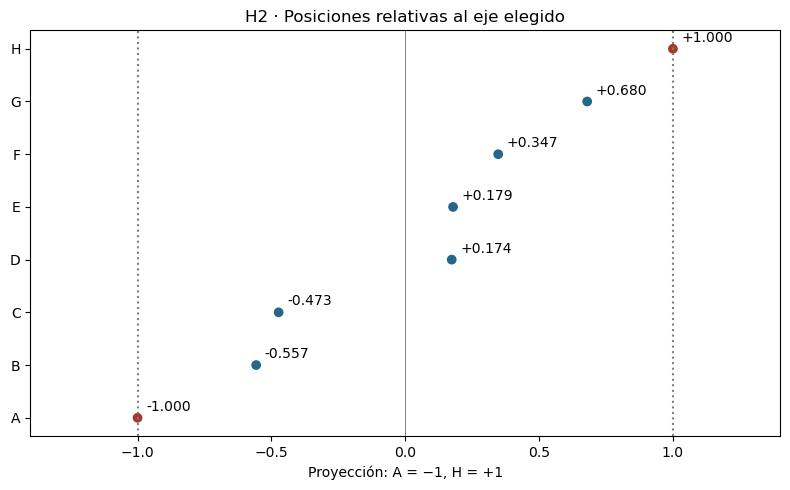

In [7]:
fig,ax=plt.subplots(figsize=(8,5))
ax.scatter(scores,range(8),c=['#a33a32' if p in 'AH' else '#246788' for p in ids])
ax.set(yticks=range(8),yticklabels=ids,xlabel='Proyección: A = −1, H = +1',title='H2 · Posiciones relativas al eje elegido')
for i,s in enumerate(scores):ax.annotate(f'{s:+.3f}',(s,i),xytext=(6,5),textcoords='offset points')
ax.axvline(0,color='gray',lw=.7);ax.axvline(-1,color='gray',ls=':');ax.axvline(1,color='gray',ls=':')
ax.margins(x=.2);fig.tight_layout();fig.savefig(OUT/'scores.png',dpi=180);plt.show()


## TEXT-08: reconstruir evidencia
Recuperamos tres pares de fragmentos próximos para el par documental más similar, y fragmentos con proyección mínima/máxima por partido. Son pistas de lectura, no explicación causal del modelo ni prueba automática de concordancia. Lea ambos extremos, las páginas completas y contraejemplos; no seleccione únicamente citas favorables.

In [8]:
evidence=[]
left,right,_=pairs[-1]
ii=[i for i,c in enumerate(chunks) if c['id_partido']==left]
jj=[i for i,c in enumerate(chunks) if c['id_partido']==right]
C=cosine_similarity(E[ii],E[jj])
for k in np.argsort(C,axis=None)[-3:][::-1]:
    i,j=np.unravel_index(k,C.shape)
    item={'tipo':'H1','coseno':float(C[i,j]),'izquierda':chunks[ii[i]],'derecha':chunks[jj[j]]}
    evidence.append(item);print(json.dumps(item,ensure_ascii=False))
cs=2*((E-midpoint)@v)/denom
for party in ids:
    ix=[i for i,c in enumerate(chunks) if c['id_partido']==party]
    for i in {min(ix,key=lambda k:cs[k]),max(ix,key=lambda k:cs[k])}:
        item={'tipo':'H2','score_fragmento':float(cs[i]),**chunks[i]}
        evidence.append(item);print(json.dumps(item,ensure_ascii=False))
(OUT/'evidencia.json').write_text(json.dumps(evidence,ensure_ascii=False,indent=2),encoding='utf-8')
(OUT/'fragmentos.json').write_text(json.dumps(chunks,ensure_ascii=False,indent=2),encoding='utf-8')
versions={x:importlib.metadata.version(x) for x in ['sentence-transformers','numpy','scikit-learn','matplotlib']}
(OUT/'ejecucion.json').write_text(json.dumps({'modelo':MODEL,'revision_modelo':getattr(model[0].auto_model.config,'_commit_hash',None),'limite_tokens':LIMIT,'versiones':versions,'corpus_sha256':hashlib.sha256((ROOT/'planes_gobierno_preparados.csv').read_bytes()).hexdigest(),'anclas':JUSTIFICACION_ANCLAS,'media_coseno':mean_cos},ensure_ascii=False,indent=2),encoding='utf-8')
# Este archivo se incorpora directamente al capítulo: no transcribir resultados a mano.
lines=[r'\begin{tabular}{lr}\toprule Partido & Proyección\\\midrule']
lines += [f'{p} & {s:+.3f}'+r'\\' for p,s in zip(ids,scores)]
lines += [r'\bottomrule\end{tabular}',f'\nMedia de similitud en los 28 pares: {mean_cos:.3f}.',f'Par más próximo: {pairs[-1][0]}--{pairs[-1][1]} ({pairs[-1][2]:.3f}).',f'Par menos próximo: {pairs[0][0]}--{pairs[0][1]} ({pairs[0][2]:.3f}).']
(OUT/'resultados.tex').write_text('\n'.join(lines),encoding='utf-8')


{"tipo": "H1", "coseno": 0.9934456230403923, "izquierda": {"id_partido": "D", "pagina": 2, "texto": "Impulsaremos descentralización, protección ambiental, vivienda, digitalización y mejores servicios públicos en todo el territorio.", "tokens": 25}, "derecha": {"id_partido": "E", "pagina": 2, "texto": "Impulsaremos descentralización, protección ambiental, vivienda, digitalización y servicios públicos eficientes en todo el territorio.", "tokens": 26}}
{"tipo": "H1", "coseno": 0.9867097836989775, "izquierda": {"id_partido": "D", "pagina": 2, "texto": "El desarrollo nacional requiere inversión privada, instituciones sólidas y un Estado eficiente que garantice oportunidades.", "tokens": 21}, "derecha": {"id_partido": "E", "pagina": 2, "texto": "El desarrollo nacional requiere inversión privada, instituciones sólidas y un Estado eficiente.", "tokens": 17}}
{"tipo": "H1", "coseno": 0.9805921773954092, "izquierda": {"id_partido": "D", "pagina": 2, "texto": "Nuestro plan propone crecimiento eco

295

### Lectura de la ejecución incluida

Media coseno **0.956**; máximo **D–E = 0.989**; mínimo **A–H = 0.917**. La plantilla y agenda compartidas producen mucha proximidad, incluso entre propuestas económicas opuestas. No corresponde decir que comparten el 95.6% de las políticas.

B = −0.557; C = −0.473; D = +0.174; E = +0.179; F = +0.347; G = +0.680. El rango de B–G es **1.237**. Son diferencias relativas compatibles con H2 sobre el eje elegido, no posiciones ideológicas validadas externamente. D y E son especialmente próximos, pero no inferimos identidad ideológica.

**Evidencia:** D y E (p. 2) comparten descentralización, protección ambiental, vivienda y digitalización; difieren entre «mejores servicios públicos» y «servicios públicos eficientes». **Contraejemplo a equivalencia general:** A propone fortalecer empresas públicas y H privatizarlas (p. 2), pese al coseno alto. Consulte las páginas completas y `evidencia.json`.

Esta lectura corresponde a la ejecución entregada. Si cambia datos o decisiones, revise estas conclusiones y `resultados/interpretacion.tex` antes de recompilar la guía.

## Qué no puede responder Text as Data
No establece causas de convergencia, intención del autor, sinceridad, cumplimiento futuro, conducta legislativa ni resultados electorales. El embedding no elimina ambigüedad, negación o sesgos. Un eje no resume toda la ideología. Con ocho planes ficticios no generalizamos a partidos reales.

Entregue: una conclusión prudente para H1 y H2; dos citas con partido y página por conclusión; un contraejemplo; una decisión de preparación que podría modificarla.

Referencia metodológica opcional para la idea de ejes semánticos: Kozlowski, Taddy y Evans (2019), *The Geometry of Culture*. No es lectura asignada ni validación de esta implementación documental.